# Trabajo Fin de Máster


**Proyecto:** Modelo de predicción de riesgo de lesión o exacerbación de enfermedades crónicas y mentales por carga de actividad física registrada en relojes inteligentes

**Autora:** Irina Calvo Carvajal

**Tutores:** Carlos Ortega y Santiago Mota

**Institución:** Universidad Computense de Madrid — NTIC Máster

**Fecha:** Septiembre, 2026


## Módulo: 01 - EDA

### Librerías

In [211]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
from pathlib import Path
import sklearn
import svy
import polars as pl

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

warnings.filterwarnings("ignore")

### Carga de datos

In [212]:
path = "data/raw/NHIS/adult24csv/adult24.csv"

base = Path.cwd() 
path = base.parent / path
# print(f"Data file path: {path}")

df_raw = pd.read_csv(path)

### Análisis de datos

In [213]:
print(f"Dimensiones: {df_raw.shape}")

Dimensiones: (32629, 630)


In [214]:
print(f"Total de observaciones: {len(df_raw)}")

Total de observaciones: 32629


In [215]:
print(f"Columnas: {len(df_raw.columns)}\n" + "\n".join(df_raw.columns.tolist()))

Columnas: 630
RATCAT_A
INCTCFLG_A
IMPINCFLG_A
PPSU
PSTRAT
WLKLEISTC_A
WLKTRANTC_A
HISPALLP_A
RACEALLP_A
ANYDIFF_A
DISAB3_A
NUMBRN1TC_A
K6SPD_A
SCHDYMSSTC_A
AFNOW
REPWRKDYTC_A
YRSINUS_A
CITZNSTP_A
PRTNREDUCP_A
SPOUSEDUCP_A
LEGMSTAT_A
MARSTAT_A
SASPPRACE_A
SASPPHISP_A
PRTNRAGETC_A
SPOUSAGETC_A
PRTNRWKFT_A
PRTNRWRK_A
SPOUSWKFT_A
SPOUSWRK_A
SPOUSESEX_A
PRTNRSEX_A
INJWRKDYTC_A
NUMINJTC_A
SHINGYEARP_A
PROXYREL2_A
PROXYFLAG_A
HHRESPSA_FLG
PCNTADWFP1_A
PCNTADWKP1_A
FDSCAT4_A
FDSCAT3_A
EMPDYSMSS3_A
EMPLSTWOR1_A
EMPWRKFT1_A
EMPWRKLSW1_A
EMPWKHRS3_A
EMDOCCUPN2_A
EMDOCCUPN1_A
EMDINDSTN2_A
EMDINDSTN1_A
DIBAGETC_A
DIFYRSTC1_A
SMKQTNP_A
SMKQTY_A
SMKECIGST_A
SMKCIGST_A
BMICATD_A
BMICAT_A
WEIGHTLBTC_A
HEIGHTTC_A
DRKHVY12M_A
DRKSTAT_A
DRK12MYR_A
DRK12MWK_A
RETAILHC12MTC_A
URGCC12MTC_A
EMERG12MTC_A
CVDSMELCHG_A
PA18_05R_A
PA18_02R_A
MODFREQW_A
MODNR_A
MODTPR_A
MODLNR_A
MODLTPR_A
MODMIN_A
VIGNR_A
VIGTPR_A
VIGLNR_A
VIGLTPR_A
VIGFREQW_A
VIGMIN_A
STRTPR_A
STRNR_A
STRFREQW_A
PCNT18UPTC
PCNTLT18TC
LANGSPECR_A


In [216]:
df_raw.describe()

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,HYPDIF_A,HYPEV_A,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,WTFA_A,POVRATTC_A
count,32629.000000,32629.000000,32629.000000,32629.000000,32629.000000,18811.000000,5158.000000,32629.000000,32629.000000,32629.000000,...,12263.000000,32629.000000,32629.000000,32629.000000,32629.0,32629.000000,32629.0,32629.0,32629.000000,32629.000000
mean,9.686996,0.031352,0.362162,31.483190,125.777192,38.649141,28.748934,2.188268,1.730424,1.498422,...,1.158526,1.633118,1.626529,2.482607,1.0,6.467222,10.0,1.0,7957.765652,4.124075
std,4.025306,0.174271,0.705139,29.277681,15.641568,51.901138,64.959799,0.976499,1.727185,0.501719,...,0.560325,0.541155,0.689749,1.061539,0.0,3.414323,0.0,0.0,5776.533149,2.966154
min,1.000000,0.000000,0.000000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,10.0,1.0,265.078000,0.000000
25%,7.000000,0.000000,0.000000,8.000000,112.000000,20.000000,10.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2.000000,1.0,4.000000,10.0,1.0,3839.683000,1.840000
50%,10.000000,0.000000,0.000000,24.000000,125.000000,30.000000,20.000000,2.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,1.0,6.000000,10.0,1.0,6507.268000,3.350000
75%,14.000000,0.000000,0.000000,48.000000,140.000000,45.000000,30.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,2.000000,3.000000,1.0,9.000000,10.0,1.0,10285.669000,5.670000
max,14.000000,1.000000,2.000000,153.000000,151.000000,999.000000,999.000000,7.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,1.0,12.000000,10.0,1.0,38138.226000,11.000000


In [217]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Columns: 630 entries, RATCAT_A to POVRATTC_A
dtypes: float64(401), int64(227), object(2)
memory usage: 156.8+ MB


In [218]:
df_raw.head(3)

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,AVGNUMCIG_A,WTFA_A,HHX,POVRATTC_A
0,9,0,2,2,122,NaN,NaN,2,1,2,...,1,1,1,1,10,1,30,5780.565,H067658,2.82
1,8,0,0,2,122,20.0,NaN,2,1,2,...,2,2,1,1,10,1,20,3994.244,H076577,2.01
2,7,0,0,2,122,30.0,NaN,2,1,1,...,1,2,1,1,10,1,20,6636.755,H019335,1.90


---
#### Columnas estructurales de encuesta

"To appropriately analyze NHIS data, it is necessary to utilize weights and variance estimation variables. This is 
because the NHIS uses a complex sample design involving stratification and clustering designed to represent the 
civilian noninstitutionalized population of the United States and not all sampled respondents respond. If data 
are not weighted, severely biased estimates may result, such as producing estimates that are not representative 
of the NHIS target population. If the correct variance estimation variables are not used, then estimates of 
precision, such as standard errors, will likely be smaller than they should be. This will make the data appear to 
be more precise and will result in more statistically significant differences between estimates and in other 
analyses that are subject to excessive Type I error (rejection of a true null hypothesis).    
Applying Sample Weight and Variance Estimation Variables in Analysis 
 
Several software packages are available for analyzing complex samples. Below are examples of computer code 
for specifying sample weight and variance estimation variables for standard error calculation code of means, 
percentages and totals with the NHIS data using SUDAAN, Stata, SPSS, SAS, and R software packages for 
illustrative purposes. The examples below use the Sample Adult sampling weight (WTFA_A) or for Sample Child 
analysis, use the Sample Child sampling weight (WTFA_C).  The limited public release design information requires a mathematical simplification that the PSUs be treated as 
if they were sampled with replacement (WR). The simplified design structure can be specified for the file with 
the following statements in selected software packages."


* WTFA_A: Sample Weight. Ajusta por probabilidad de selección, no respuesta y calibración poblacional para representar a la población de EE.UU.
* PSTRAT: Pseudo estrato. Captura la estratificación geográfica del diseño muestral.
* PPSU: Unidad primaria de muestreo. Identifica la agrupación por conglomerados (clusters).

Para aplicar esto en Python, hay que utilizar alguna librería que lo permita para operaciones en EDA como statsmodels o samplics.
En muchos casos, scikit-learn nos deja usar el sample_weight también.

---

In [219]:
sample_vars = [
    'WTFA_A', # sample weight
    'PSTRAT', # pseudostato
    'PPSU' # unidad de muestreo primaria
]

In [220]:
# Variables to explore

physical_activity_vars = [
    "MODFREQW_A", # moderate activity frequency per week
    'MODMIN_A', # moderate activity minutes per time
    "MODNR_A", # moderate activity number of times per week
    'MODTPR_A', # moderate activity minutes per time (moderate time period / unit)
    'MODLNR_A', # moderate activity number of times per week (light/moderate)
    'MODLTPR_A', # moderate activity minutes per time (light/moderate time period / unit)
    "VIGFREQW_A", # vigorous activity frequency per week
    'VIGMIN_A', # vigorous activity minutes per time
    'VIGNR_A', # vigorous activity number of times per week
    'VIGTPR_A', # vigorous activity minutes per time (vigorous time period / unit)
    'VIGLNR_A', # vigorous activity number of times per week (light/vigorous)
    'VIGLTPR_A', # vigorous activity minutes per time (light/vigorous time period / unit)
    'STRFREQW_A', # strength training frequency per week
    'STRNR_A', # strength training number of times per week
]

In [221]:
psych_distress_vars = [
    "ANXEV_A", # Ansiedad
    "DEPEV_A", # Depresión
    "SAD_A", # Variables Kessler
    "NERVOUS_A", 
    "RESTLESS_A", 
    "HOPELESS_A", 
    "EFFORT_A", 
    "WORTHLESS_A"
]

In [222]:
respiratory_vars = [
    'ASEV_A', # Asma
    'ASAT12M_A', # Asma diagnosticada en los últimos 12 meses
    'COPDEV_A', # EPOC (Enfermedad Pulmonar Obstructiva Crónica), enfisema o bronquitis
]

In [223]:
metabolic_vars = [
    'DIBEV_A', # Diabetes
    'PREDIB_A', # Prediabetes
    'HYPEV_A', # Hipertensión
    'CHLEV_A' # Colesterol alto
]

cardiovasc_vars = [
    'CHDEV_A', # Enfermedad coronaria
    'ANGEV_A', # Angina de pecho
    'MIEV_A', # Infarto de miocardio (Ataque al corazón)
    'STREV_A' # Ictus / Accidente cerebrovascular (Stroke)
]


In [224]:
basic_vars = [
    'AGEP_A', # Age
    'SEX_A', # Sex
    'BMICAT_A', # BMI category
    'HEIGHTTC_A', # Height (total centimeters)
]


In [225]:
fatigue_vars = [
    'CFSEV_A', # Síndrome de Fatiga Crónica o Encefalomielitis Miálgica (ME/CFS)
    'FGEFRQTRD_A' # Frecuencia de cansancio last 3m
]

auto_infl_vars = [
    'ARTHEV_A', # Artritis, artritis reumatoide, gota, lupus o fibromialgia
    'CROHNSEV_A', # Enfermedad de Crohn
    'ULCCOLEV_A', # Colitis Ulcerosa
    'PSOREV_A' # Psoriasis
]

In [226]:
injury_vars = [
    "ANYINJURY_A", # Tuvo alguna lesión
    "REPSTRAIN_A", # Lesiones por esfuerzo repetitivo /3m
    "REPLIMIT_A", # RSI limitó actividades por >=24h
    "REPSAWDOC_A", # evaluado por médico por RSI
    "INJSPORTS_A", # lesión fue por deporte
    "INJLIMIT_A", # limitó actividades por >= 24h
    "INJSAWDOC_A", # evaluado por médico
    "INJER_A", # atendido en emergencias por lesion
    "INJHOSP_A", # atendido en hospital por lesion
    "INJBONES_A", # hueso roto/ severidad
    "INJSTITCH_A", # puntadas por lesión/ severidad
    "TBILCDCMG_A", # Si tras un golpe en la cabeza quedó aturdido, perdió el conocimiento o tuvo pérdida de memoria /12m
    "TBISPORT_A", # Si evento TBI sucedió entrenando/compitiendo
    "TBIHLSBMC_A", # Golpe con dolor de cabeza/sensibilidad a luz-ruido/problemas de equilibrio/cambios de ánimo /12m
    "TBILEAGUE_A", # en evento equipo/liga
    "TBIEVAL_A" # evaluado por médico
]

In [227]:
selected_vars = sample_vars + physical_activity_vars + psych_distress_vars + respiratory_vars + metabolic_vars + cardiovasc_vars + basic_vars + fatigue_vars + auto_infl_vars + injury_vars

df_selected = df_raw[selected_vars]

print(f"Possible target variables:\n")
for col in selected_vars:
    print(f"{col}: {df_selected[col].value_counts()}")

Possible target variables:

WTFA_A: WTFA_A
6688.172     4
31466.980    3
3752.308     3
34764.502    3
3677.464     3
            ..
5172.310     1
6408.530     1
30575.820    1
6025.736     1
2800.466     1
Name: count, Length: 32124, dtype: int64
PSTRAT: PSTRAT
109    1128
144    1095
151    1045
149     978
100     882
113     871
119     857
122     827
114     825
108     793
107     772
101     765
148     758
129     731
134     713
147     669
146     658
140     655
137     644
117     641
143     634
118     631
110     622
126     607
131     596
132     582
121     575
130     574
141     570
124     567
135     567
106     561
133     559
150     556
104     547
136     539
102     531
105     527
138     527
120     525
115     504
123     504
127     481
111     475
145     468
142     431
103     418
116     399
125     363
139     360
128     275
112     247
Name: count, dtype: int64
PPSU: PPSU
1      1921
2      1543
3      1226
4       949
10      883
       ... 
118

In [228]:
print(f"Selected Dataset Shape: {df_selected.shape}")

Selected Dataset Shape: (32629, 62)


In [229]:
print(f"Columns: {df_selected.columns.tolist()}")

Columns: ['WTFA_A', 'PSTRAT', 'PPSU', 'MODFREQW_A', 'MODMIN_A', 'MODNR_A', 'MODTPR_A', 'MODLNR_A', 'MODLTPR_A', 'VIGFREQW_A', 'VIGMIN_A', 'VIGNR_A', 'VIGTPR_A', 'VIGLNR_A', 'VIGLTPR_A', 'STRFREQW_A', 'STRNR_A', 'ANXEV_A', 'DEPEV_A', 'SAD_A', 'NERVOUS_A', 'RESTLESS_A', 'HOPELESS_A', 'EFFORT_A', 'WORTHLESS_A', 'ASEV_A', 'ASAT12M_A', 'COPDEV_A', 'DIBEV_A', 'PREDIB_A', 'HYPEV_A', 'CHLEV_A', 'CHDEV_A', 'ANGEV_A', 'MIEV_A', 'STREV_A', 'AGEP_A', 'SEX_A', 'BMICAT_A', 'HEIGHTTC_A', 'CFSEV_A', 'FGEFRQTRD_A', 'ARTHEV_A', 'CROHNSEV_A', 'ULCCOLEV_A', 'PSOREV_A', 'ANYINJURY_A', 'REPSTRAIN_A', 'REPLIMIT_A', 'REPSAWDOC_A', 'INJSPORTS_A', 'INJLIMIT_A', 'INJSAWDOC_A', 'INJER_A', 'INJHOSP_A', 'INJBONES_A', 'INJSTITCH_A', 'TBILCDCMG_A', 'TBISPORT_A', 'TBIHLSBMC_A', 'TBILEAGUE_A', 'TBIEVAL_A']


In [230]:
df_selected.head(3)

,WTFA_A,PSTRAT,PPSU,MODFREQW_A,MODMIN_A,MODNR_A,MODTPR_A,MODLNR_A,MODLTPR_A,VIGFREQW_A,...,INJSAWDOC_A,INJER_A,INJHOSP_A,INJBONES_A,INJSTITCH_A,TBILCDCMG_A,TBISPORT_A,TBIHLSBMC_A,TBILEAGUE_A,TBIEVAL_A
0,5780.565,122,2,6,30.0,6,2,30.0,1.0,94,...,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN
1,3994.244,122,2,94,NaN,0,0,NaN,NaN,94,...,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN
2,6636.755,122,2,94,NaN,0,0,NaN,NaN,94,...,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN


---
#### Codificación CDC para respuestas

1 = Sí (Tiene la condición)

2 = No (No la tiene)

7 = Refused (Se negó a contestar)

9 = Don't Know (No sabe)

* algunas respuestas incluyen 9s a la izquierda para llenar el espacio

---

#### Clasificación de variables

In [231]:
# Numéricas y categóricas
numeric_vars = df_selected.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df_selected.select_dtypes(include=['object']).columns.tolist()

print(f"Sample vars: {len(sample_vars)} \nNumeric vars: {len(numeric_vars)} \nCategorical vars: {len(categorical_vars)}")

for var in numeric_vars:
    print(f"{var}: {df_selected[var].value_counts()}")


Sample vars: 3 
Numeric vars: 62 
Categorical vars: 0
WTFA_A: WTFA_A
6688.172     4
31466.980    3
3752.308     3
34764.502    3
3677.464     3
            ..
5172.310     1
6408.530     1
30575.820    1
6025.736     1
2800.466     1
Name: count, Length: 32124, dtype: int64
PSTRAT: PSTRAT
109    1128
144    1095
151    1045
149     978
100     882
113     871
119     857
122     827
114     825
108     793
107     772
101     765
148     758
129     731
134     713
147     669
146     658
140     655
137     644
117     641
143     634
118     631
110     622
126     607
131     596
132     582
121     575
130     574
141     570
124     567
135     567
106     561
133     559
150     556
104     547
136     539
102     531
105     527
138     527
120     525
115     504
123     504
127     481
111     475
145     468
142     431
103     418
116     399
125     363
139     360
128     275
112     247
Name: count, dtype: int64
PPSU: PPSU
1      1921
2      1543
3      1226
4       949
1

Por la naturaleza de las variables utilizadas en NHIS, las variables categóricas están siendo interpretadas como numéricas, por lo que se deben separar manualmente

In [232]:
numeric_vars = [
    'MODFREQW_A', # int
    'MODMIN_A', # float
    'MODNR_A', # int
    'MODLNR_A', # float
    'VIGFREQW_A', # int
    'VIGMIN_A', # int -> float
    'VIGNR_A', # int
    'VIGLNR_A', # float -> int
    'STRFREQW_A', # int
    'STRNR_A', # int
    'AGEP_A', # int
    'HEIGHTTC_A' # int
]

categorical_vars = [col for col in df_selected.columns if col not in numeric_vars and col not in sample_vars]

# print(f"Sample vars: {len(sample_vars)} \nNumeric vars: {len(numeric_vars)} \nCategorical vars: {len(categorical_vars)}")

print(f"Sample vars: {len(sample_vars)} ------------------------")
print(f"Numeric vars: {len(numeric_vars)} ------------------------")
for var in numeric_vars:
    print(f"{var}: {df_selected[var].value_counts()}")
print(f"Categorical vars: {len(categorical_vars)} ------------------------")
for var in categorical_vars:
    print(f"{var}: {df_selected[var].value_counts()}")


Sample vars: 3 ------------------------
Numeric vars: 12 ------------------------
MODFREQW_A: MODFREQW_A
94    8786
7     5593
3     4173
2     3471
1     2650
5     2195
4     2075
0     1192
98     801
6      544
14     436
95     170
21     155
96     132
99      81
28      72
97      32
10      16
12      12
15       8
20       6
11       5
23       4
13       4
9        3
17       3
22       2
8        2
27       2
25       2
16       1
18       1
Name: count, dtype: int64
MODMIN_A: MODMIN_A
60.0     6675
30.0     5655
45.0     2409
120.0    1683
20.0     1323
         ... 
58.0        1
26.0        1
46.0        1
68.0        1
48.0        1
Name: count, Length: 75, dtype: int64
MODNR_A: MODNR_A
0       8786
1       6365
3       4497
2       4325
5       2274
4       2258
7       2042
9998     801
6        574
9995     170
9996     132
9999      81
10        59
15        33
9997      32
12        27
30        26
8         22
20        20
14        12
13         7
365        7
9  

#### Duplicados

In [233]:
print(f"Filas duplicadas: {df_selected.duplicated().sum()}")

Filas duplicadas: 0


Columnas con valores nulos:
* MODMIN_A
* MODLNR_A
* MODLTPR_A
* VIGMIN_A
* VIGLNR_A
* VIGLTPR_A
* ASAT12M_A
* REPSAWDOC_A
* INJSPORTS_A
* INJSAWDOC_A
* INJER_A
* INJHOSP_A
* INJBONES_A
* INJSTITCH_A
* TBISPORT_A
* TBIHLSBMC_A
* TBILEAGUE_A
* TBIEVAL_A


In [234]:
print(df_selected.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Data columns (total 62 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   WTFA_A       32629 non-null  float64
 1   PSTRAT       32629 non-null  int64  
 2   PPSU         32629 non-null  int64  
 3   MODFREQW_A   32629 non-null  int64  
 4   MODMIN_A     22797 non-null  float64
 5   MODNR_A      32629 non-null  int64  
 6   MODTPR_A     32629 non-null  int64  
 7   MODLNR_A     22797 non-null  float64
 8   MODLTPR_A    22797 non-null  float64
 9   VIGFREQW_A   32629 non-null  int64  
 10  VIGMIN_A     11312 non-null  float64
 11  VIGNR_A      32629 non-null  int64  
 12  VIGTPR_A     32629 non-null  int64  
 13  VIGLNR_A     11312 non-null  float64
 14  VIGLTPR_A    11312 non-null  float64
 15  STRFREQW_A   32629 non-null  int64  
 16  STRNR_A      32629 non-null  int64  
 17  ANXEV_A      32629 non-null  int64  
 18  DEPEV_A      32629 non-null  int64  
 19  SAD_

#### Códigos especiales

*Nota metodológica: códigos 95/96 en variables de actividad física*

Los códigos 95/96 (y análogos 995/996, 9995/9996) en las variables de actividad 
física no corresponden al código "96 = Not available" documentado para altura/peso 
(HEIGHTTC_A), que es específico de esas variables por razones de confidencialidad. 
Basado en el patrón general de NHIS de usar códigos altos para "valor fuera de 
rango" (ej. año de vacuna <2006 recodificado a 9996, según srvydesc-508.pdf p.88) 
y en la documentación histórica de IPUMS sobre "Extreme value" para estas mismas 
preguntas de actividad física, se interpretan como valores de frecuencia 
extrema/top-coded, no sustantivos para el análisis, y se recodifican como NaN.

In [235]:
# special_codes = {
#     7: 'refused',
#     9: 'dont_know',
#     94: 'no_activity',
#     96: 'not_ascertained',
#     97: 'not_ascertained',
#     98: 'not_ascertained',
#     99: 'not_ascertained',
#     9995: 'not_ascertained',
#     9996: 'not_ascertained',
#     9997: 'not_ascertained',
#     9998: 'not_ascertained',
# } ??????


recode_nan = {
    # Actividad física
    'MODFREQW_A': [95, 97, 98, 99],
    'MODMIN_A': [996, 997, 998, 999],
    'MODNR_A': [9995, 9997, 9998, 9999],
    'MODTPR_A': [5, 7, 8, 9], # 6 significa que no puede hacer actividad, posible lesion/enfermedad
    'MODLNR_A': [995, 996, 997, 998, 999],
    'MODLTPR_A': [5, 6, 7, 8, 9],

    'VIGFREQW_A': [95, 97, 98, 99],
    'VIGMIN_A': [996, 997, 998, 999],
    'VIGNR_A': [9995, 9997, 9998, 9999],
    'VIGTPR_A': [5, 7, 8, 9], # 6 significa que no puede hacer actividad, posible lesion/enfermedad
    'VIGLNR_A': [995, 996, 997, 998, 999],
    'VIGLTPR_A': [5, 6, 7, 8, 9],

    'STRFREQW_A': [95, 97, 98, 99],
    'STRNR_A': [9995, 9997, 9998, 9999],

    # Kessler vars y enfermedades
    'SAD_A': [7, 8, 9],
    'NERVOUS_A': [7, 8, 9],
    'RESTLESS_A': [7, 8, 9],
    'HOPELESS_A': [7, 8, 9],
    'EFFORT_A': [7, 8, 9],
    'WORTHLESS_A': [7, 8, 9],
    'ASEV_A': [7, 8, 9],
    'ASAT12M_A': [7, 8, 9],
    'COPDEV_A': [7, 8, 9],
    'DIBEV_A': [7, 8, 9],
    'PREDIB_A': [7, 8, 9],
    'HYPEV_A': [7, 8, 9],
    'CHLEV_A': [7, 8, 9],
    'CHDEV_A': [7, 8, 9],
    'ANGEV_A': [7, 8, 9],
    'MIEV_A': [7, 8, 9],
    'STREV_A': [7, 8, 9],
    'ANXEV_A': [7, 8, 9],
    'DEPEV_A': [7, 8, 9],
    'ARTHEV_A': [7, 8, 9],
    'CROHNSEV_A': [7, 8, 9],
    'ULCCOLEV_A': [7, 8, 9],
    'PSOREV_A': [7, 8, 9],
    'CFSEV_A': [7, 8, 9],
    'ANYINJURY_A': [7, 8, 9],
    "REPSTRAIN_A":  [7, 8, 9],
    "REPLIMIT_A": [7, 8, 9], 
    "REPSAWDOC_A": [7, 8, 9],
    "INJSPORTS_A": [7, 8, 9],
    "INJLIMIT_A": [7, 8, 9],
    "INJSAWDOC_A": [7, 8, 9],
    "INJER_A": [7, 8, 9],
    "INJHOSP_A": [7, 8, 9],
    "INJBONES_A": [7, 8, 9],
    "INJSTITCH_A": [7, 8, 9],
    "TBILCDCMG_A": [7, 8, 9],
    "TBISPORT_A": [7, 8, 9],
    "TBIHLSBMC_A": [7, 8, 9],
    "TBILEAGUE_A": [7, 8, 9],
    "TBIEVAL_A": [7, 8, 9],

    # Demograficas
    'AGEP_A': [97, 98, 99], # -> 85 sigue siendo válido
    'SEX_A': [7, 8, 9],
    'HEIGHTTC_A': [96, 97, 98, 99],
    'BMICAT_A': [9],

    # Fatiga
    'FGEFRQTRD_A': [7, 8, 9]
}

recode_zero = {
    'MODFREQW_A': 94,
    'VIGFREQW_A': 94,
    'STRFREQW_A': 94
}

recode_incap = {
    'MODTPR_A':   6,
    'VIGTPR_A':   6,
    'MODFREQW_A': 96,
    'MODNR_A':    9996,
    'VIGFREQW_A': 96,
    'VIGNR_A':    9996,
    'STRFREQW_A': 96,
    'STRNR_A': 9996
}

In [236]:
def recode_special_codes(df: pd.DataFrame, dict_to_nan: dict, dict_to_zero: dict, dict_to_neg: dict) -> pd.DataFrame:
    """
    Recibe un DataFrame, un diccionario de codigos especiales a recodificar a cero y otro 
        diccionario a recodificar a NaN.
    Retorna una copia del DataFrame recibido, con valores recodificados a cero o NaNs de acuerdo a 
        los diccionarios recibidos.
    """
    df_recoded = df.copy()

    # Recodificar a NaNs
    for col, codes in dict_to_nan.items():
        if col not in df_recoded.columns:
            continue
        recoded = df_recoded[col].isin(codes).sum()
        df_recoded[col] = df_recoded[col].replace(codes, np.nan)
        if recoded > 0:
            print(f"{col}: {recoded} filas recodificadas a NaN.")

    # Recodificar a ceros
    for col, code in dict_to_zero.items():
        if col not in df_recoded.columns:
            continue
        recoded = (df_recoded[col] == code).sum()
        df_recoded[col] = df_recoded[col].replace(code, 0)
        if recoded > 0:
            print(f"{col}: {recoded} filas recodificadas de {code} a 0.")

    # Recodificar a -1 por incapacidad
    for col, code in dict_to_neg.items():
        if col not in df_recoded.columns:
            continue
        recoded = (df_recoded[col] == code).sum()
        df_recoded[col] = df_recoded[col].replace(code, -1)
        if recoded > 0:
            print(f"{col}: {recoded} filas recodificadas de {code} a -1.")

    return df_recoded

In [237]:
df_clean_special_codes = recode_special_codes(df_selected, recode_nan, recode_zero, recode_incap)

missing = df_clean_special_codes.isna().sum().sort_values(ascending=False)
print(missing)

MODFREQW_A: 1084 filas recodificadas a NaN.
MODMIN_A: 110 filas recodificadas a NaN.
MODNR_A: 1084 filas recodificadas a NaN.
MODTPR_A: 1084 filas recodificadas a NaN.
MODLNR_A: 110 filas recodificadas a NaN.
MODLTPR_A: 110 filas recodificadas a NaN.
VIGFREQW_A: 1003 filas recodificadas a NaN.
VIGMIN_A: 47 filas recodificadas a NaN.
VIGNR_A: 1003 filas recodificadas a NaN.
VIGTPR_A: 1003 filas recodificadas a NaN.
VIGLNR_A: 47 filas recodificadas a NaN.
VIGLTPR_A: 47 filas recodificadas a NaN.
STRFREQW_A: 961 filas recodificadas a NaN.
STRNR_A: 961 filas recodificadas a NaN.
SAD_A: 676 filas recodificadas a NaN.
NERVOUS_A: 696 filas recodificadas a NaN.
RESTLESS_A: 689 filas recodificadas a NaN.
HOPELESS_A: 700 filas recodificadas a NaN.
EFFORT_A: 731 filas recodificadas a NaN.
WORTHLESS_A: 719 filas recodificadas a NaN.
ASEV_A: 31 filas recodificadas a NaN.
ASAT12M_A: 7 filas recodificadas a NaN.
COPDEV_A: 40 filas recodificadas a NaN.
DIBEV_A: 29 filas recodificadas a NaN.
PREDIB_A: 

In [238]:
def verify_missing_structural(df_original, freq_col, duration_col, no_activity=94):
    mascara_no_activity = df_original[freq_col] == no_activity
    mascara_real_zero = df_original[freq_col] == 0

    print(f"Columna {duration_col} depende de {freq_col}:")
    print(f"Grupo 1 (no hace actividad): {mascara_no_activity.sum()}")
    print(f"Grupo 2 (freq=0 redondeado): {mascara_real_zero.sum()}")
    print(f"NaN en Grupo 1: {df_original.loc[mascara_no_activity, duration_col].isna().sum()}")
    print(f"NaN en Grupo 2: {df_original.loc[mascara_real_zero, duration_col].isna().sum()}")


In [239]:
# Verificación de missing values por branching estructural de la encuesta

verify_missing_structural(df_selected, 'VIGFREQW_A', 'VIGMIN_A')
verify_missing_structural(df_selected, 'MODFREQW_A', 'MODMIN_A')

Columna VIGMIN_A depende de VIGFREQW_A:
Grupo 1 (no hace actividad): 20179
Grupo 2 (freq=0 redondeado): 1891
NaN en Grupo 1: 20179
NaN en Grupo 2: 0
Columna MODMIN_A depende de MODFREQW_A:
Grupo 1 (no hace actividad): 8786
Grupo 2 (freq=0 redondeado): 1192
NaN en Grupo 1: 8786
NaN en Grupo 2: 0


Estos missing que quedan tienen sentido por la estructura de la encuesta. Hay preguntas que no van a llegar a ser respondidas por algunos encuestados, por el branching de la estructura de preguntas.

#### Estadísticas descriptivas aplicando variables de muestreo

In [240]:
# from statsmodels.stats.weightstats import DescrStatsW
# from samplics.estimation import TaylorEstimator


def weighted_quantile(values: np.ndarray, weights: np.ndarray, quantiles: float) -> np.ndarray:
    """
    """
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    weighted_quantiles = np.cumsum(weights) - 0.5 * weights
    weighted_quantiles /= np.sum(weights)
    return np.interp(quantiles, weighted_quantiles, values)

def describe_with_sampling(df: pd.DataFrame, columns: list, weight_col: str = 'WTFA_A', 
                           strat_col: str = 'PSTRAT', psu_col: str = 'PPSU') -> pd.DataFrame:
    """
    """

    # Validaciones
    required_columns = [weight_col, strat_col, psu_col]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas de muestreo: {', '.join(missing_columns)}")

    design = svy.Design(
        stratum = strat_col,
        psu = psu_col,
        wgt = weight_col
    )
    sample = svy.Sample(data = pl.from_pandas(df), design = design)

    summary = []

    for col in columns:
        if col not in df.columns:
            print(f"Columna {col} no encontrada en DataFrame.")
            continue

        try:
            media = sample.estimation.mean(col, drop_nulls=True).to_polars()
            mediana = sample.estimation.median(col, drop_nulls=True).to_polars()
            mascara = df[col].notna() & df[weight_col].notna()
            data = df.loc[mascara, col].to_numpy()
            pesos = df.loc[mascara, weight_col].to_numpy()
            q1 = weighted_quantile(data, pesos, 0.25) # aproximados sin diseño muestral completo
            q3 = weighted_quantile(data, pesos, 0.75)

        except Exception as e:
            print(f"Error al calcular estadísticas ponderadas para la columna {col}: {e}")
            continue


        summary.append({
            'Variable': col,
            'Media': media['est'][0],
            'SE': media['se'][0],
            'CV': media['cv'][0],
            'LCI': media['lci'][0],
            'UCI': media['uci'][0],
            'Mínimo': df[col].min(),
            'Máximo': df[col].max(),
            '25%': q1,
            '50%': mediana['est'][0],
            '75%': q3,
            'IQR': q3 - q1
        })

    return pd.DataFrame(summary)


In [241]:
df_descriptive = describe_with_sampling(df_clean_special_codes, numeric_vars, weight_col='WTFA_A', strat_col='PSTRAT', psu_col='PPSU')
display(df_descriptive.round(3))

,Variable,Media,SE,CV,LCI,UCI,Mínimo,Máximo,25%,50%,75%,IQR
0,MODFREQW_A,2.960,0.030,0.010,2.902,3.018,-1.0,28.0,0.0,2.0,5.0,5.0
1,MODMIN_A,61.333,0.614,0.010,60.127,62.539,1.0,720.0,30.0,45.0,60.0,30.0
2,MODNR_A,2.366,0.037,0.015,2.294,2.438,-1.0,365.0,0.0,2.0,3.0,3.0
3,MODLNR_A,26.408,0.289,0.011,25.841,26.975,1.0,240.0,2.0,30.0,40.0,38.0
4,VIGFREQW_A,0.963,0.016,0.016,0.932,0.994,-1.0,28.0,0.0,0.0,1.0,1.0
5,VIGMIN_A,57.904,0.615,0.011,56.695,59.112,1.0,720.0,30.0,45.0,60.0,30.0
6,VIGNR_A,1.019,0.023,0.022,0.974,1.063,-1.0,365.0,0.0,0.0,1.0,1.0
7,VIGLNR_A,25.592,0.370,0.014,24.865,26.318,1.0,270.0,2.0,30.0,35.0,33.0
8,STRFREQW_A,1.341,0.019,0.014,1.304,1.377,-1.0,28.0,0.0,0.0,2.0,2.0
9,STRNR_A,1.231,0.025,0.021,1.181,1.281,-1.0,365.0,0.0,0.0,2.0,2.0


#### Plots

In [242]:
# Diccionario de labels por variable
labels_dict = {
    # --- Actividad moderada ---
    'MODFREQW_A': {-1: 'No puede'}, # numérica
    'MODMIN_A': {}, # numérica
    'MODNR_A': {-1: 'No puede'}, # numérica
    'MODTPR_A': {-1: 'No puede', 0: 'Nunca', 1: 'Por día', 2: 'Por semana', 3: 'Por mes', 4: 'Por año'},
    'MODLNR_A': {}, # numérica
    'MODLTPR_A': {1: 'Minutos', 2: 'Horas'},

    # --- Actividad vigorosa ---
    'VIGFREQW_A': {-1: 'No puede'},
    'VIGMIN_A': {}, # numérica
    'VIGNR_A': {-1: 'No puede'},
    'VIGTPR_A': {-1: 'No puede', 0: 'Nunca', 1: 'Por día', 2: 'Por semana', 3: 'Por mes', 4: 'Por año'},
    'VIGLNR_A': {},# numérica
    'VIGLTPR_A': {1: 'Minutos', 2: 'Horas'},

    # --- Fortalecimiento muscular ---
    'STRFREQW_A': {-1: 'No puede'},
    'STRNR_A': {-1: 'No puede'},

    # --- Escala K6 (malestar psicológico) ---
    'SAD_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'NERVOUS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'RESTLESS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'HOPELESS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'EFFORT_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'WORTHLESS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},

    # --- Condiciones "Ever had" ---
    'ANXEV_A': {1: 'Sí', 2: 'No'},
    'DEPEV_A': {1: 'Sí', 2: 'No'},
    'ASEV_A': {1: 'Sí', 2: 'No'},
    'ASAT12M_A': {1: 'Sí', 2: 'No'},
    'COPDEV_A': {1: 'Sí', 2: 'No'},
    'DIBEV_A': {1: 'Sí', 2: 'No'},
    'PREDIB_A': {1: 'Sí', 2: 'No'},
    'HYPEV_A': {1: 'Sí', 2: 'No'},
    'CHLEV_A': {1: 'Sí', 2: 'No'},
    'CHDEV_A': {1: 'Sí', 2: 'No'},
    'ANGEV_A': {1: 'Sí', 2: 'No'},
    'MIEV_A': {1: 'Sí', 2: 'No'},
    'STREV_A': {1: 'Sí', 2: 'No'},

    # --- Demográficas ---
    'AGEP_A': {}, # numérica
    'SEX_A': {1: 'Hombre', 2: 'Mujer'},
    'BMICAT_A': {1: 'Bajo peso', 2: 'Peso normal', 3: 'Sobrepeso', 4: 'Obesidad'},
    'HEIGHTTC_A': {}, # numérica

    # --- Fatiga y condiciones restantes ---
    'CFSEV_A': {1: 'Sí', 2: 'No'},
    'FGEFRQTRD_A': {1: 'Nunca', 2: 'Algunos días', 3: 'La mayoría de días', 4: 'Todos los días'},
    'ARTHEV_A': {1: 'Sí', 2: 'No'},
    'CROHNSEV_A': {1: 'Sí', 2: 'No'},
    'ULCCOLEV_A': {1: 'Sí', 2: 'No'},
    'PSOREV_A': {1: 'Sí', 2: 'No'},
    'ANYINJURY_A': {1: 'Sí', 2: 'No'},
    'REPSTRAIN_A': {1: 'Sí', 2: 'No'},
    'REPLIMIT_A': {1: 'Sí', 2: 'No'},
    "REPSAWDOC_A": {1: 'Sí', 2: 'No'},
    "INJSPORTS_A": {1: 'Sí', 2: 'No'},
    "INJLIMIT_A": {1: 'Sí', 2: 'No'},
    "INJSAWDOC_A": {1: 'Sí', 2: 'No'},
    "INJER_A": {1: 'Sí', 2: 'No'},
    "INJHOSP_A": {1: 'Sí', 2: 'No'},
    "INJBONES_A": {1: 'Sí', 2: 'No'},
    "INJSTITCH_A": {1: 'Sí', 2: 'No'},
    "TBILCDCMG_A": {1: 'Sí', 2: 'No'},
    "TBISPORT_A": {1: 'Sí', 2: 'No'},
    "TBIHLSBMC_A": {1: 'Sí', 2: 'No'},
    "TBILEAGUE_A": {1: 'Sí', 2: 'No'},
    "TBIEVAL_A": {1: 'Sí', 2: 'No'},
}


In [243]:
# grupos temáticos de variables
variable_groups = {
    'actividad_fisica': physical_activity_vars,
    'salud_mental': psych_distress_vars,
    'respiratorio': respiratory_vars,
    'demograficas': basic_vars,
    'lesiones': injury_vars,
    'factores_riesgo_metabolico': metabolic_vars,
    'eventos_cardiovasculares': cardiovasc_vars,
    'fatiga': fatigue_vars,
    'autoinmune_inflamatorio': auto_infl_vars
}

In [244]:
# Estilo para plots
sns.set_theme(style="whitegrid", font_scale=1.0)
matplotlib.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#4a4a4a',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
})

COLOR_BASE = "#3B6DB3"
COLOR_MEDIAN = "#D8622C"

In [ ]:
var_descriptions = {
    'MODFREQW_A': 'Frecuencia actividad moderada (veces/semana)',
    'MODMIN_A': 'Duración actividad moderada (minutos)',
    'MODNR_A': 'Actividad moderada - número (crudo)',
    'MODTPR_A': 'Actividad moderada - unidad de tiempo',
    'MODLNR_A': 'Duración actividad moderada - número (crudo)',
    'MODLTPR_A': 'Duración actividad moderada - unidad de tiempo',
    'VIGFREQW_A': 'Frecuencia actividad vigorosa (veces/semana)',
    'VIGMIN_A': 'Duración actividad vigorosa (minutos)',
    'VIGNR_A': 'Actividad vigorosa - número (crudo)',
    'VIGTPR_A': 'Actividad vigorosa - unidad de tiempo',
    'VIGLNR_A': 'Duración actividad vigorosa - número (crudo)',
    'VIGLTPR_A': 'Duración actividad vigorosa - unidad de tiempo',
    'STRFREQW_A': 'Frecuencia fortalecimiento muscular (veces/semana)',
    'STRNR_A': 'Fortalecimiento muscular - número (crudo)',

    'ANXEV_A': 'Ansiedad (diagnóstico)',
    'DEPEV_A': 'Depresión (diagnóstico)',
    'SAD_A': 'Frecuencia sentirse triste (K6)',
    'NERVOUS_A': 'Frecuencia sentirse nervioso (K6)',
    'RESTLESS_A': 'Frecuencia sentirse inquieto (K6)',
    'HOPELESS_A': 'Frecuencia sentirse sin esperanza (K6)',
    'EFFORT_A': 'Frecuencia sentir que todo requiere esfuerzo (K6)',
    'WORTHLESS_A': 'Frecuencia sentirse inútil (K6)',

    'ASEV_A': 'Asma (diagnóstico)',
    'ASAT12M_A': 'Asma diagnosticada en últimos 12 meses',
    'COPDEV_A': 'EPOC / enfisema / bronquitis crónica',

    'DIBEV_A': 'Diabetes (diagnóstico)',
    'PREDIB_A': 'Prediabetes (diagnóstico)',
    'HYPEV_A': 'Hipertensión (diagnóstico)',
    'CHLEV_A': 'Colesterol alto (diagnóstico)',
    'CHDEV_A': 'Enfermedad coronaria (diagnóstico)',
    'ANGEV_A': 'Angina de pecho (diagnóstico)',
    'MIEV_A': 'Infarto de miocardio (diagnóstico)',
    'STREV_A': 'Ictus / accidente cerebrovascular (diagnóstico)',

    'AGEP_A': 'Edad (años)',
    'SEX_A': 'Sexo',
    'BMICAT_A': 'Categoría de índice de masa corporal',
    'HEIGHTTC_A': 'Altura (pulgadas)',

    'CFSEV_A': 'Síndrome de fatiga crónica (diagnóstico)',
    'FGEFRQTRD_A': 'Frecuencia de sentirse cansado (últimos 3 meses)',
    'ARTHEV_A': 'Artritis / artritis reumatoide / gota / lupus / fibromialgia',
    'CROHNSEV_A': 'Enfermedad de Crohn (diagnóstico)',
    'ULCCOLEV_A': 'Colitis ulcerosa (diagnóstico)',
    'PSOREV_A': 'Psoriasis (diagnóstico)',

    'ANYINJURY_A': 'Tuvo alguna lesión en últimos 3m',
    'REPSTRAIN_A': 'Lesión por esfuerzo repetitivo RSI (diagnóstico)',
    'REPLIMIT_A': 'RSI limitó actividad por >= 24h',
    'REPSAWDOC_A': 'Evaluado por médico por RSI',
    'INJSPORTS_A': 'Lesión por deporte',
    'INJLIMIT_A': 'Lesión limitó actividad por >= 24h', 
    'INJSAWDOC_A': 'Lesión evaluada por médico', 
    'INJER_A': 'Lesión atendida en emergencias', 
    'INJHOSP_A': 'Lesión atendida en hospital', 
    'INJBONES_A': 'Lesión con hueso roto', 
    'INJSTITCH_A': 'Lesión con puntadas',
    'TBILCDCMG_A': 'TBI con aturdimiento/perdida de memoria/conocimiento en 12m',
    'TBISPORT_A': 'TBI sucedió entrenando o compitiendo', 
    'TBIHLSBMC_A': 'TBI produjo dolor, sensibilidad, problemas de equilibrio en 12m', 
    'TBILEAGUE_A': 'Evento TBI durante actividad de equipo/liga',
    'TBIEVAL_A': 'Evento TBI evaluado por médico' 
}

##### Distribuciones

In [246]:
def plot_numeric_var(df, col, ax):
    data = df[col].dropna()
    sns.histplot(data, ax=ax, color=COLOR_BASE, linewidth=0.2, bins=30)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.set_title(col)
    median = data.median()
    ax.axvline(median, color=COLOR_MEDIAN, linestyle='--', linewidth=1.0, alpha=0.85)

def plot_categoric_var(df, col, ax, labels):
    data = df[col].value_counts().sort_index()
    col_labels = [labels.get(col, {}).get(i, str(i)) for i in data.index]
    ax.bar(col_labels, data.values, color=COLOR_BASE, linewidth=0.2)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(col)
    # ax.tick_params(axis='x', labelsize=10, rotation=45)
    plt.setp(ax.get_xticklabels(), rotation=60, ha='right', fontsize=10)

def plot_hybrid_var(df, col, ax, labels):
    data = df[col].dropna()
    no_by_incap = (data == -1).sum()
    regular_numeric = data[data >= 0]
    sns.histplot(regular_numeric, ax=ax, color=COLOR_BASE, linewidth=0.2, bins=30)
    #barra extra para mostrara a quienes no realizan actividad por incapacidad
    xmin, xmax = ax.get_xlim()
    xrange = xmax - xmin
    minusonepad = max(xrange * 0.10, 3)
    xmargin = max(xrange * 0.05, 1.5)
    xoffset = -(minusonepad + xmargin)/ 2
    ax.set_xlim(xoffset - xmargin, xmax)
    ax.bar(x=[xoffset], height=[no_by_incap], width=xmargin * 0.8, color=COLOR_MEDIAN)
    xticks = [t for t in ax.get_xticks() if t >= 0] #forzando el -1 en los histplots
    ax.set_xticks([xoffset] + xticks)
    ax.set_xticklabels([-1] + [str(int(t)) for t in xticks])
    ytext = ax.get_ylim()[1] * 0.03
    ax.text(xoffset, ytext , str(no_by_incap), ha='center', va='bottom', fontsize=8, 
            color=COLOR_MEDIAN, fontweight = 'bold')
    ##
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(col)
    # ax.tick_params(axis='x', labelsize=10, rotation=45)

def plot_variable_group(df, group_name, variable_groups, labels, numeric_vars, categorical_vars, 
                        var_descriptions, column_num):
    columns = variable_groups[group_name]
    n_rows = -(-len(columns) // column_num)

    fig, axes = plt.subplots(n_rows, column_num, figsize=(15, 3.6 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]

        if col in categorical_vars:
            var_type = "categorical"
        elif col in numeric_vars:
            if labels.get(col, {}):
                var_type = "hybrid"
            else:
                var_type = "numeric"
        else:
            raise ValueError(f"{col} no está en numeric_vars ni categorical_vars.")
        # print(col, ' -> ', var_type)

        if var_type == "categorical":
            plot_categoric_var(df, col, ax, labels)
        elif var_type == "numeric":
            plot_numeric_var(df, col, ax)
        else:
            plot_hybrid_var(df, col, ax, labels)
            # continue

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(group_name, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    leyenda = '\n'.join(f"{col}: {var_descriptions.get(col, 'sin descripción')}" for col in columns)
    fig.text(0.02, -0.02, leyenda, fontsize=8, va='top', ha='left', family='monospace')


    plt.show()



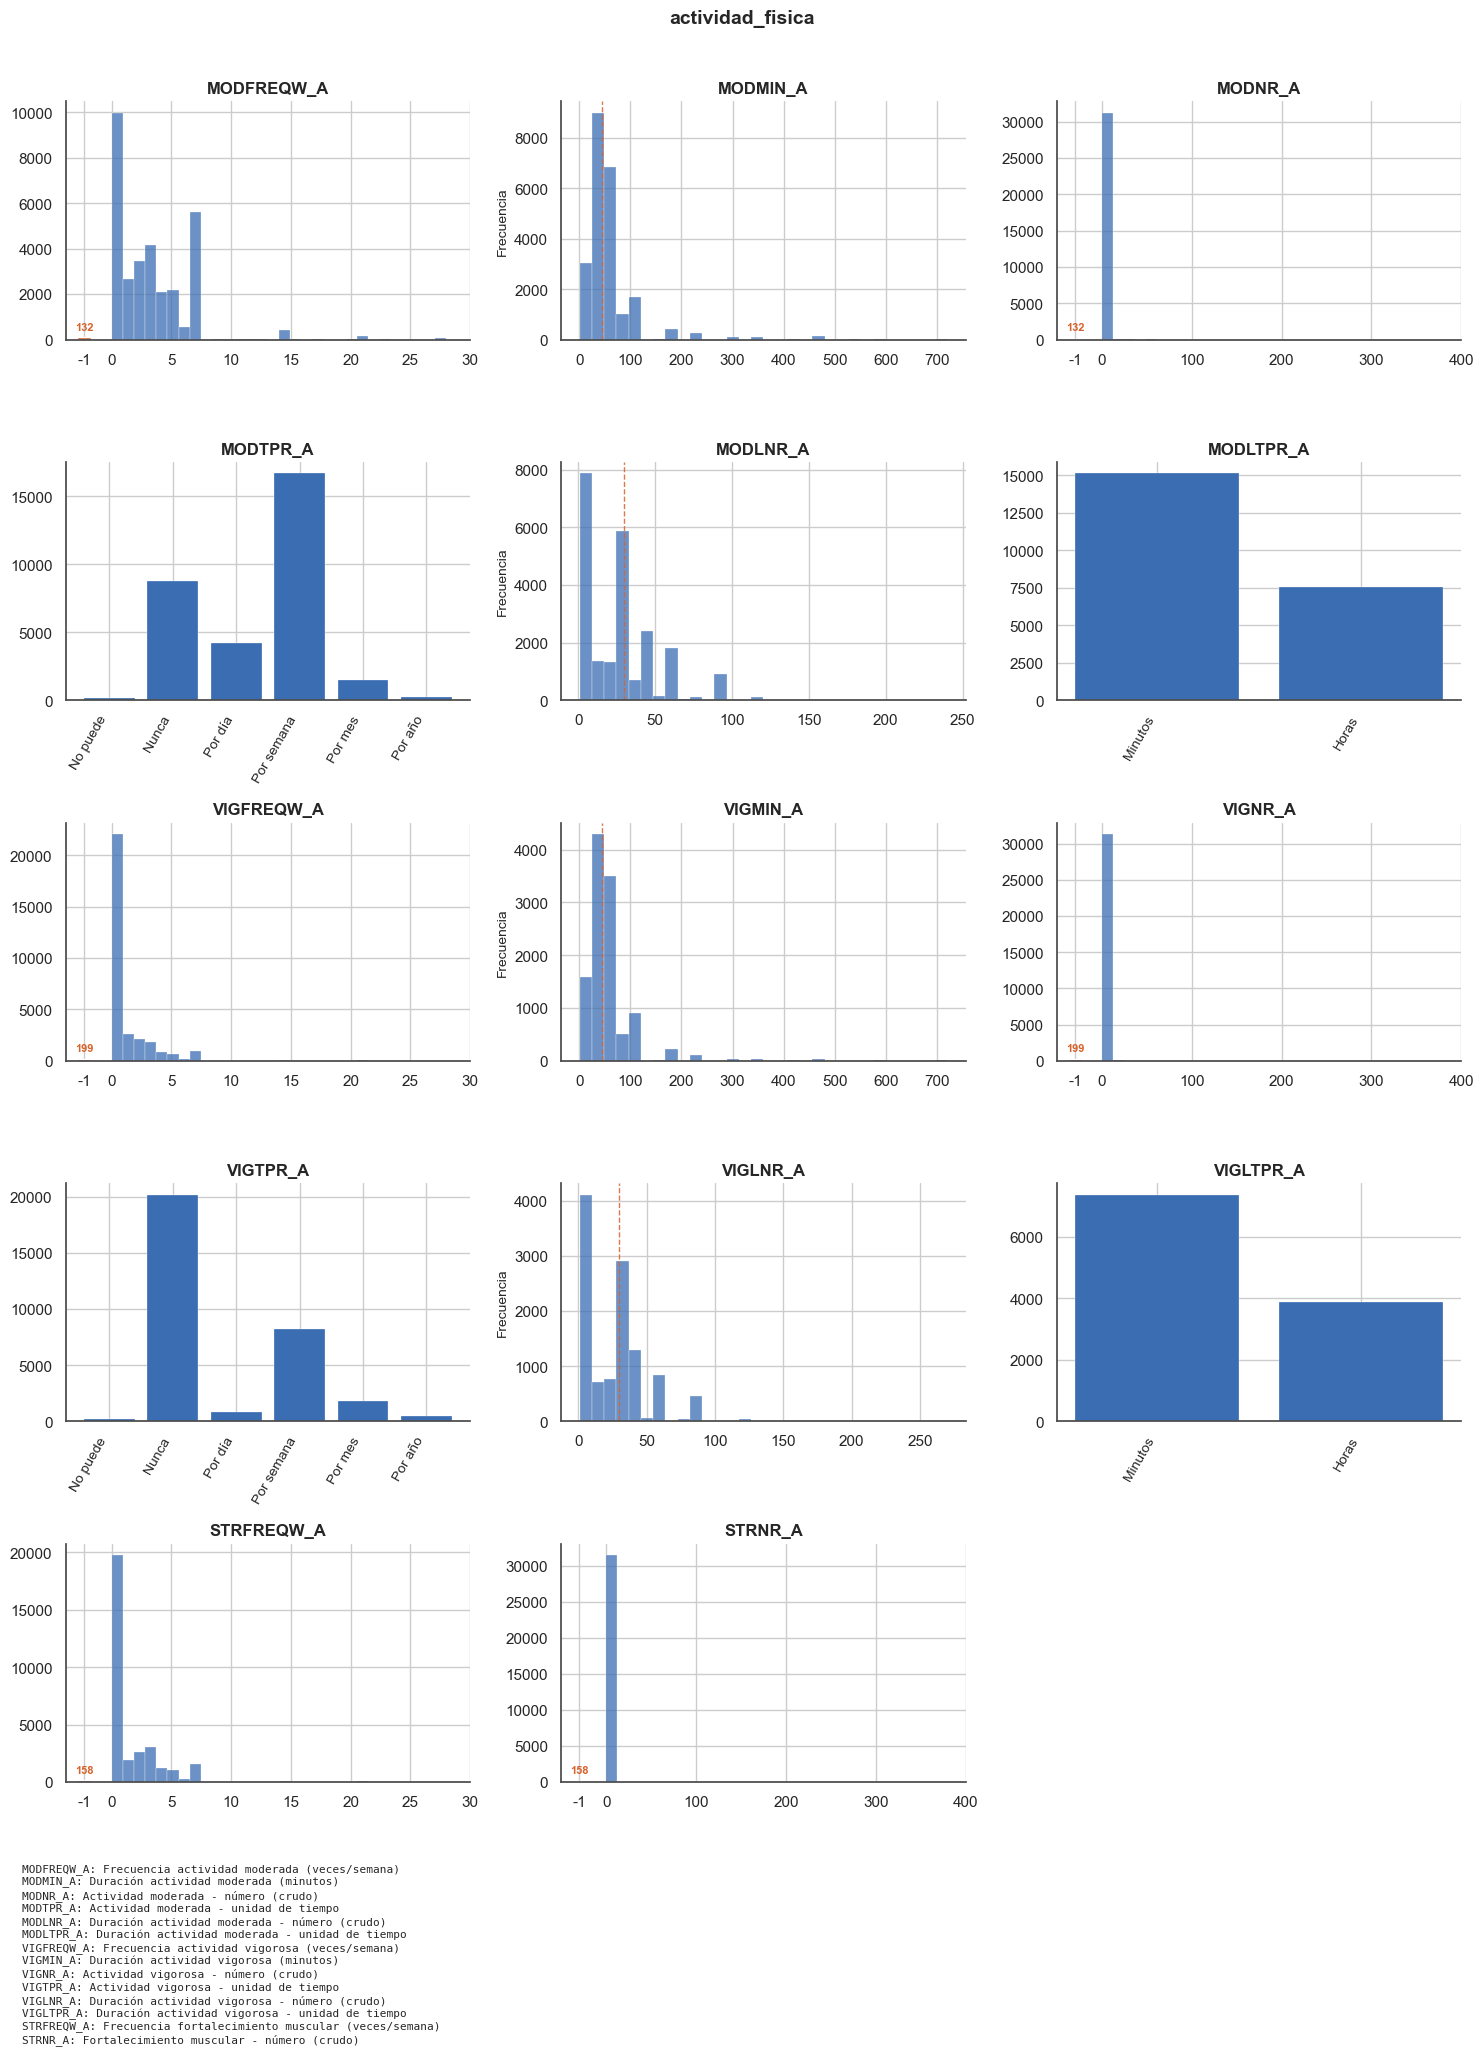

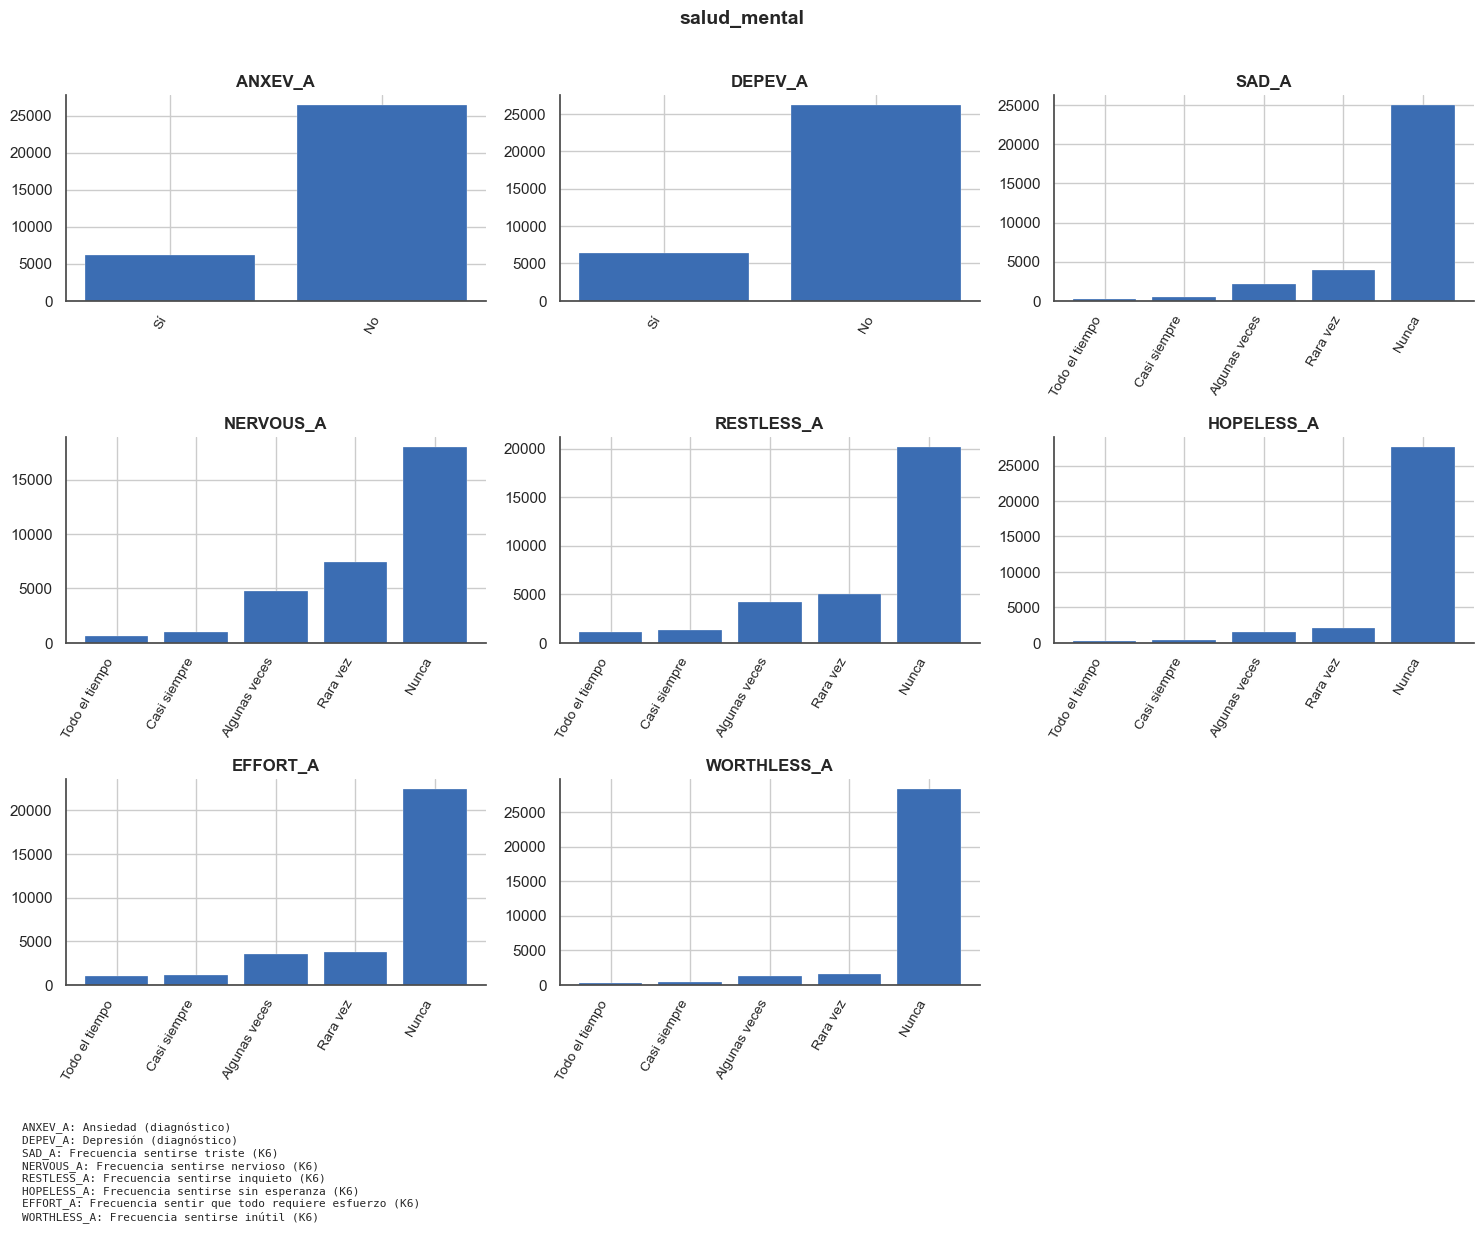

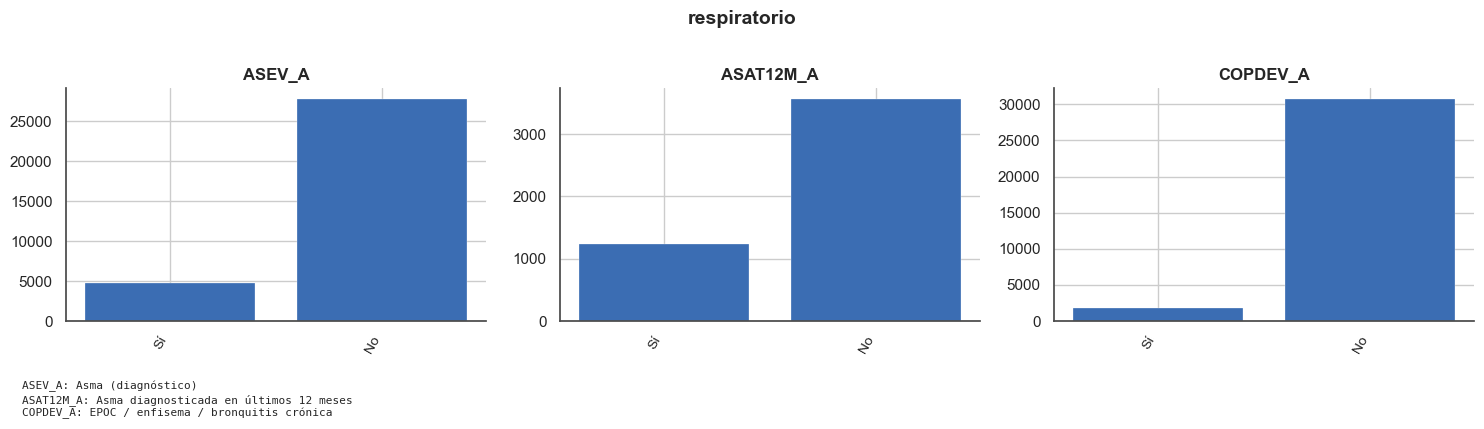

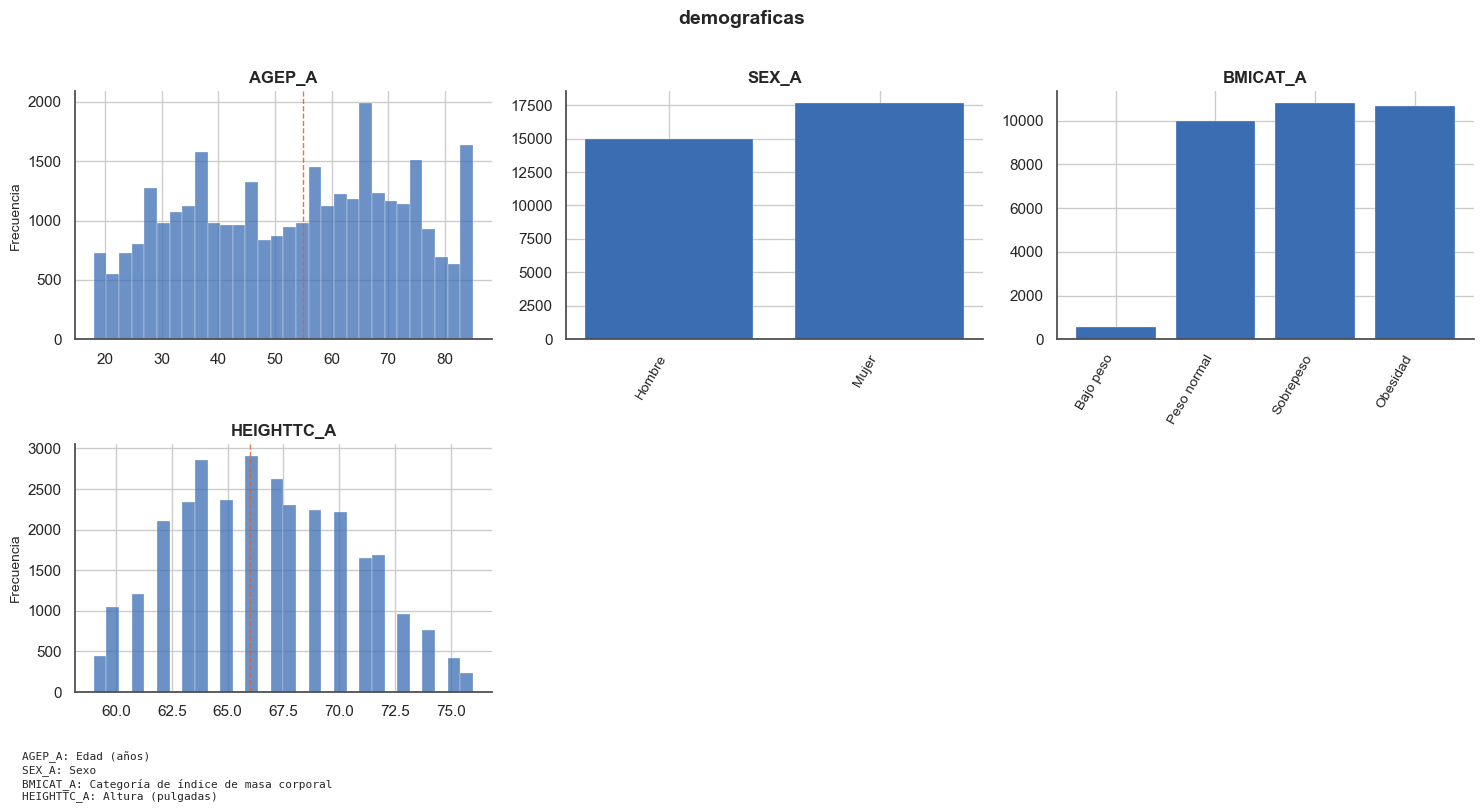

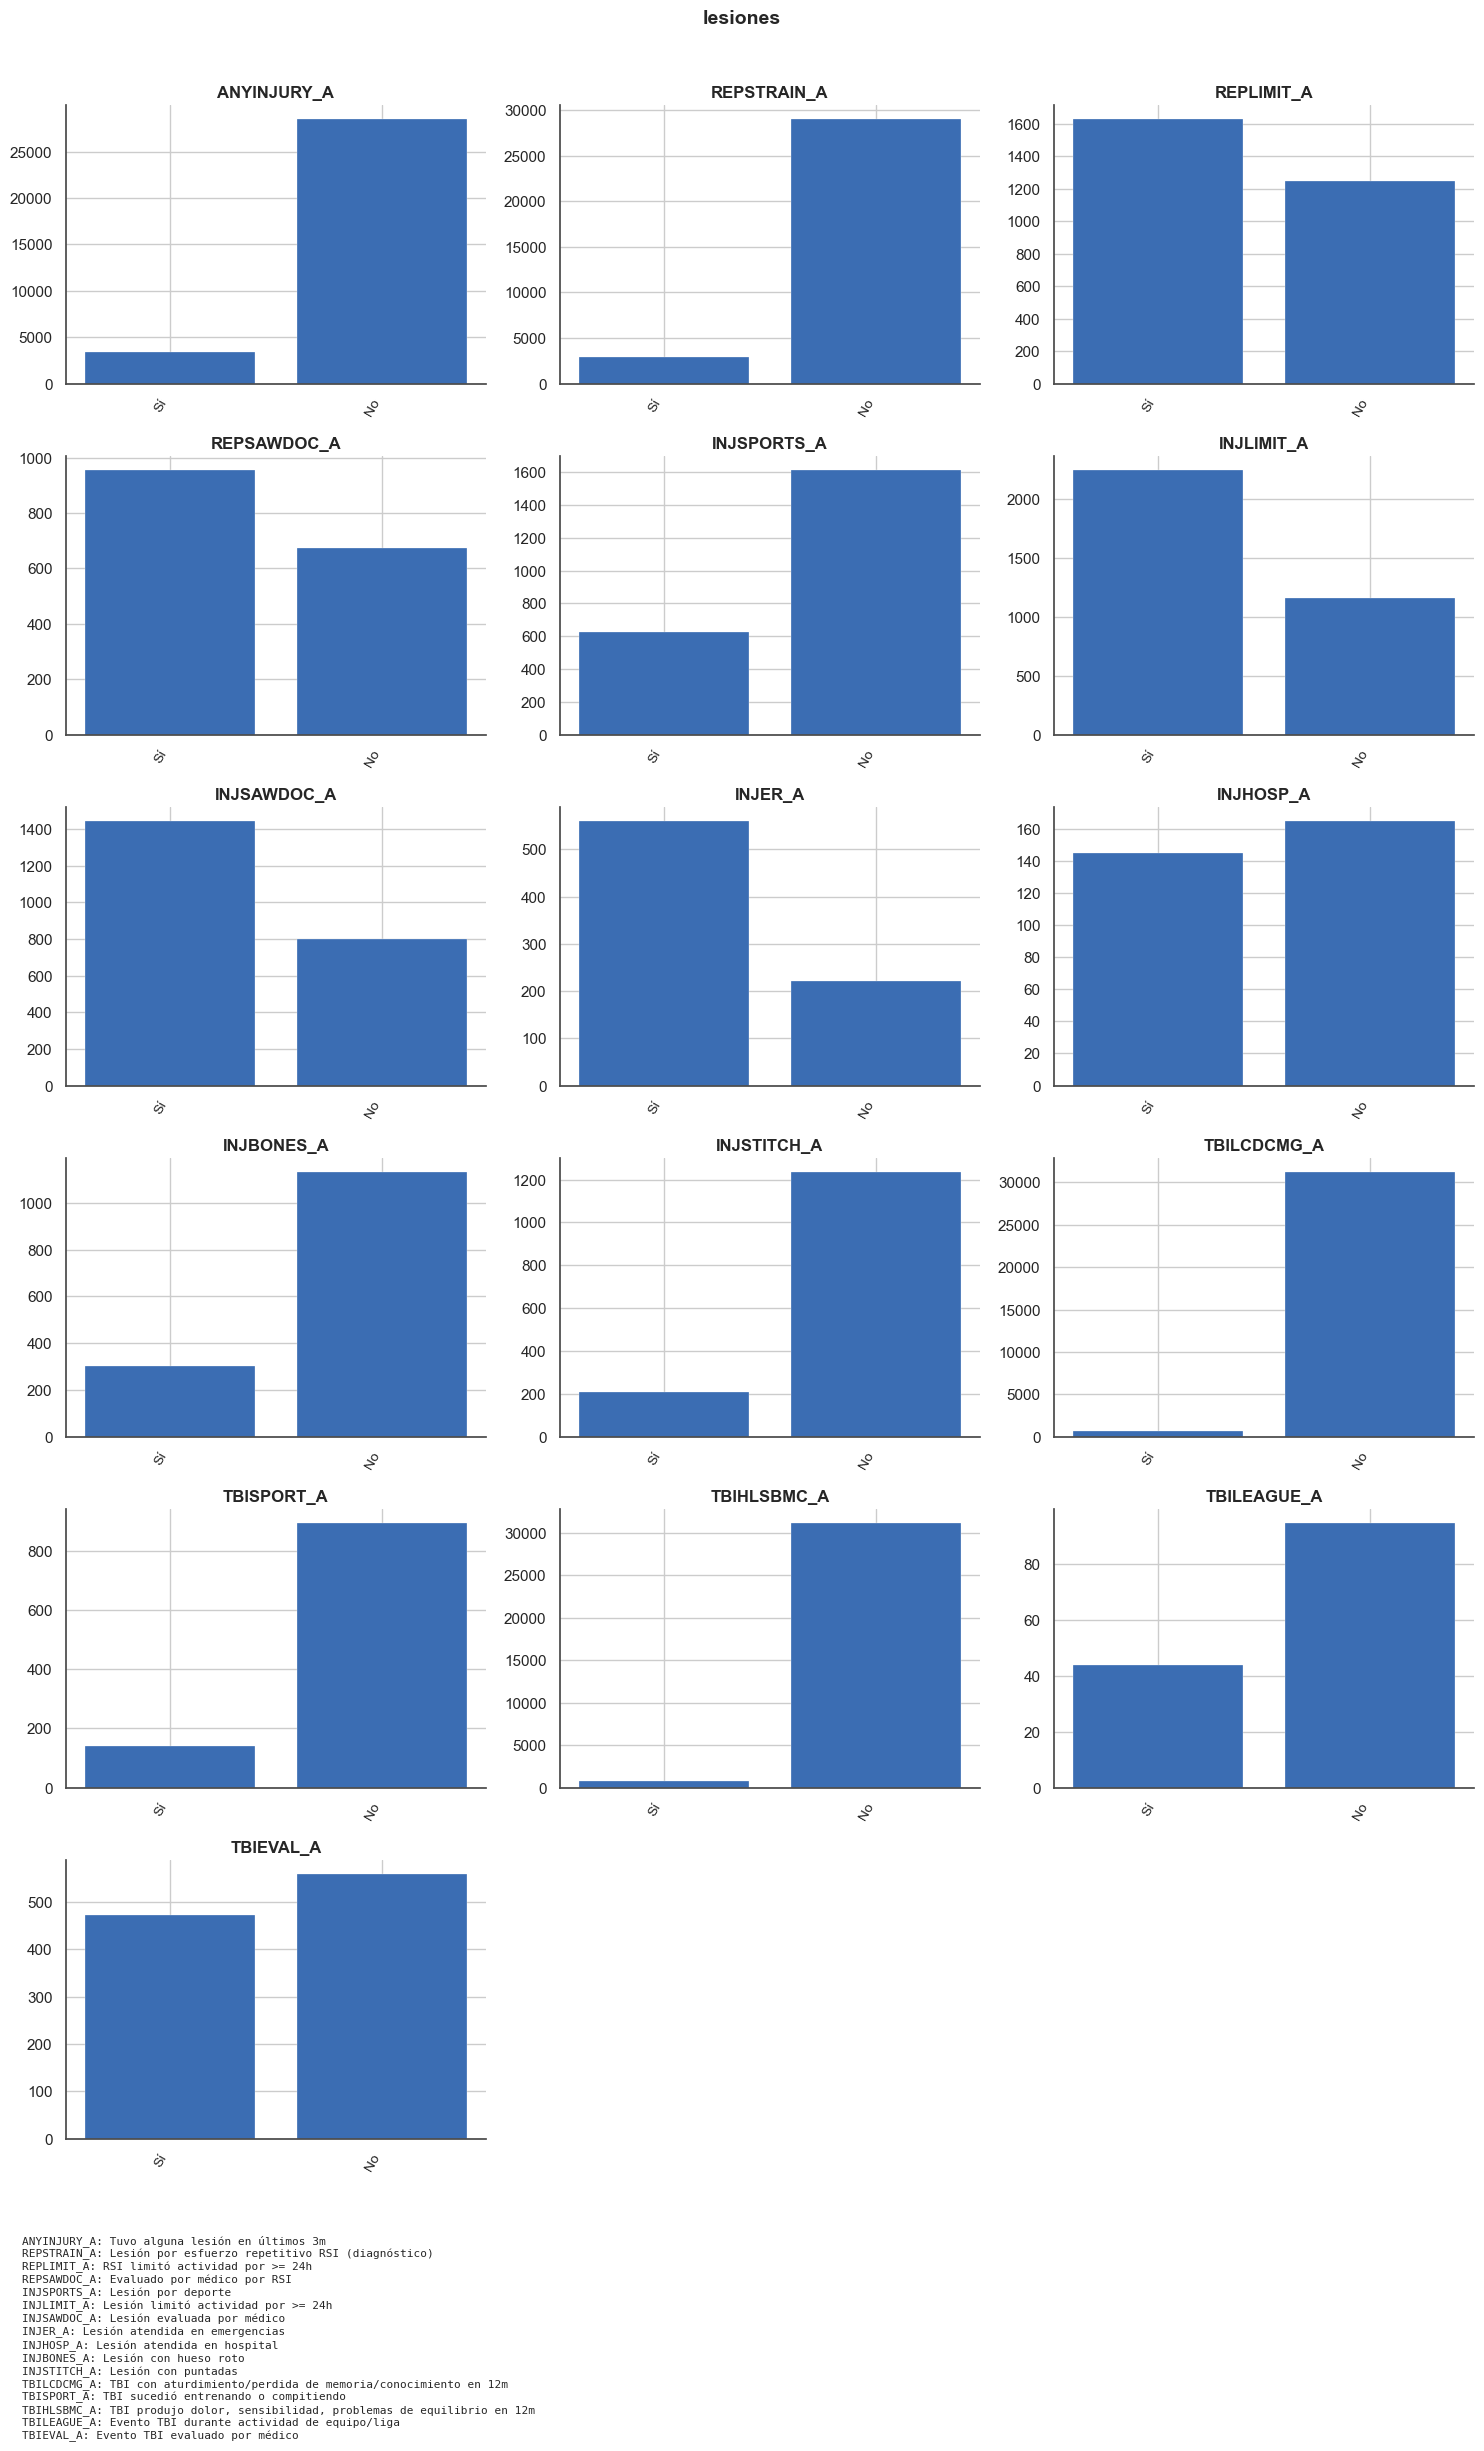

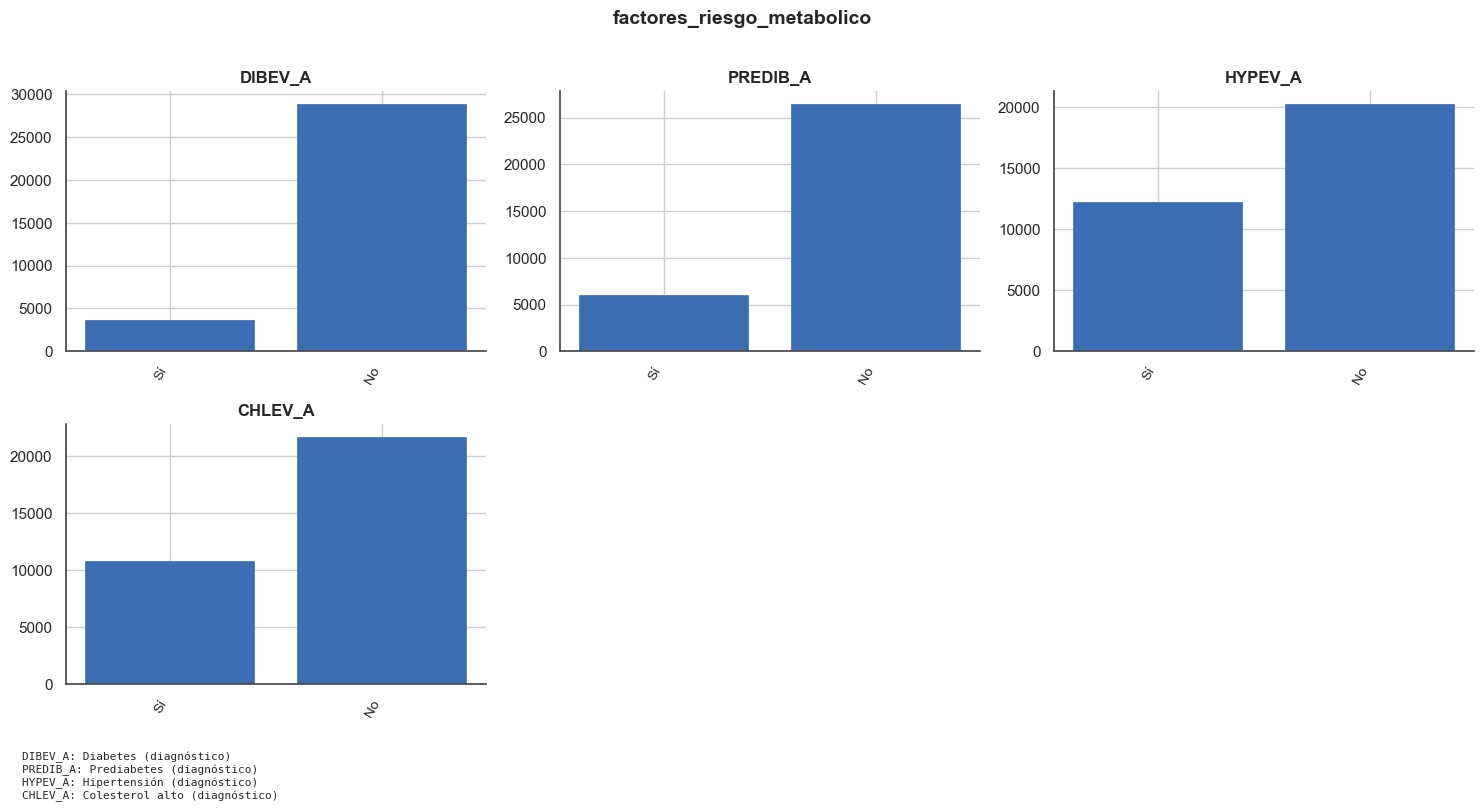

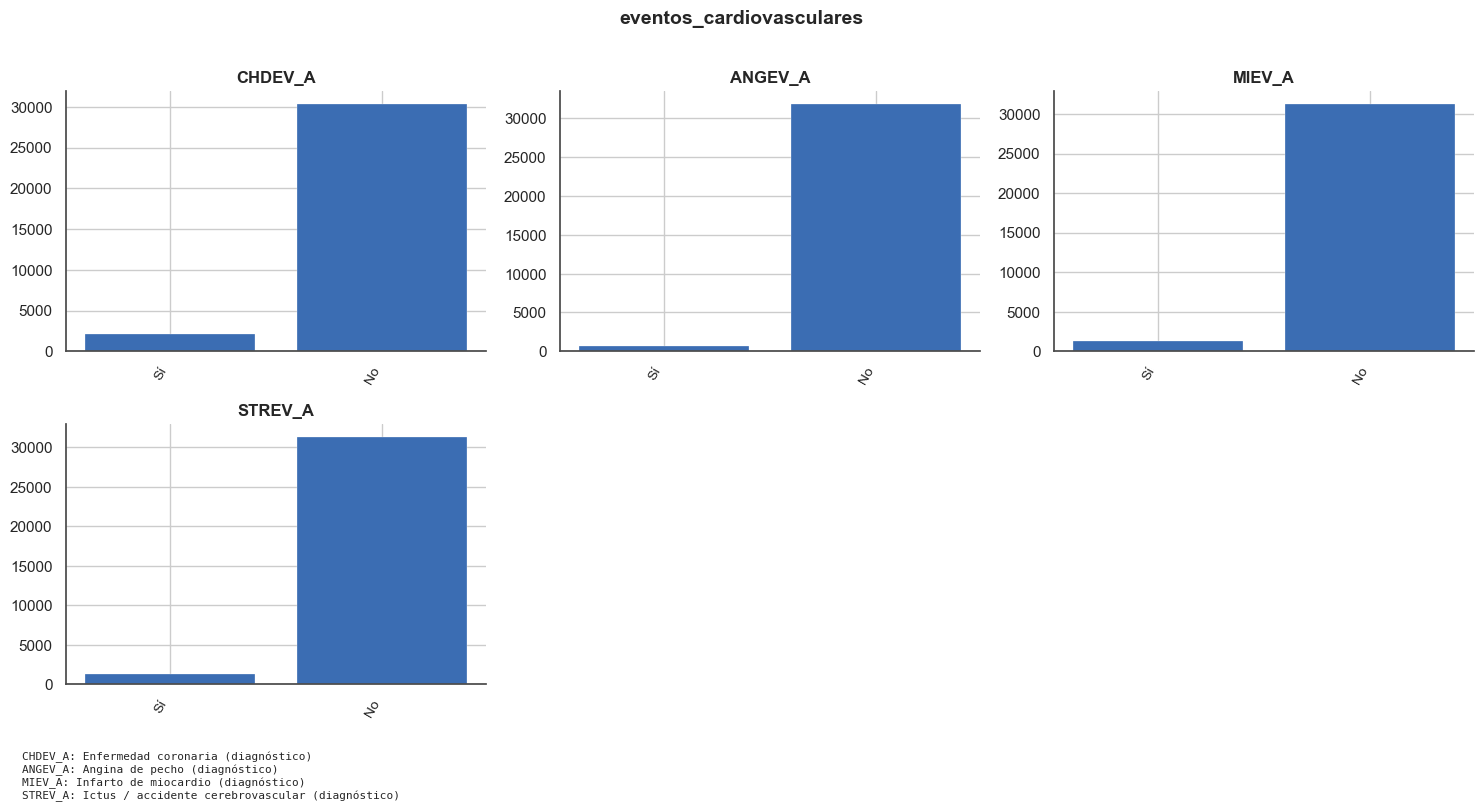

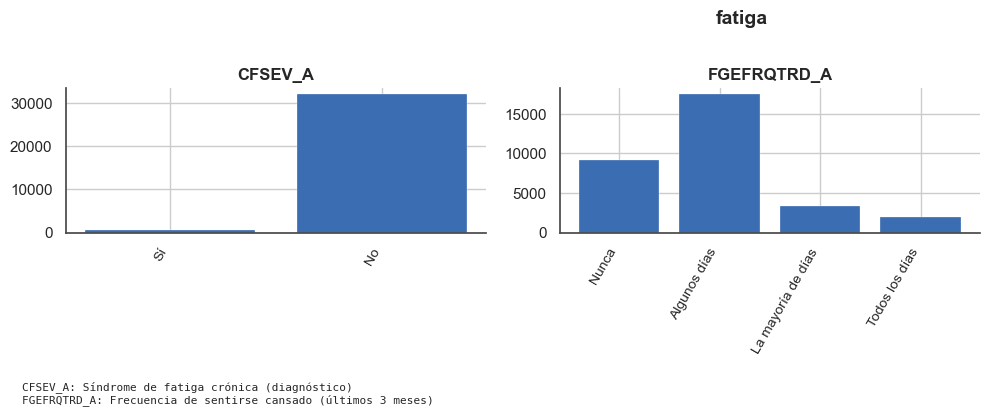

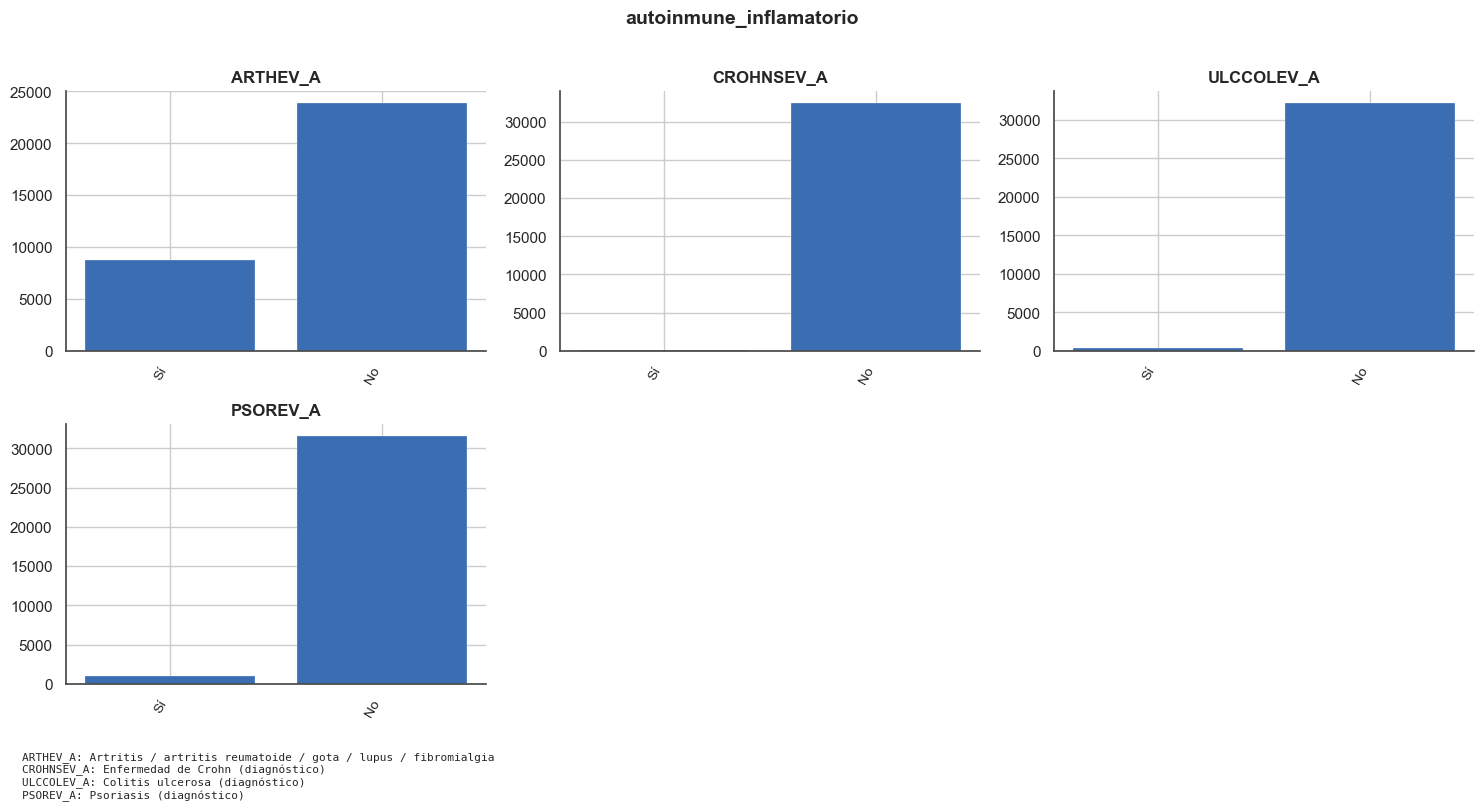

In [247]:
for group_name in variable_groups:
    plot_variable_group(df_clean_special_codes, group_name, variable_groups, 
                        labels_dict, numeric_vars, categorical_vars, var_descriptions, 3)

##### Boxplots

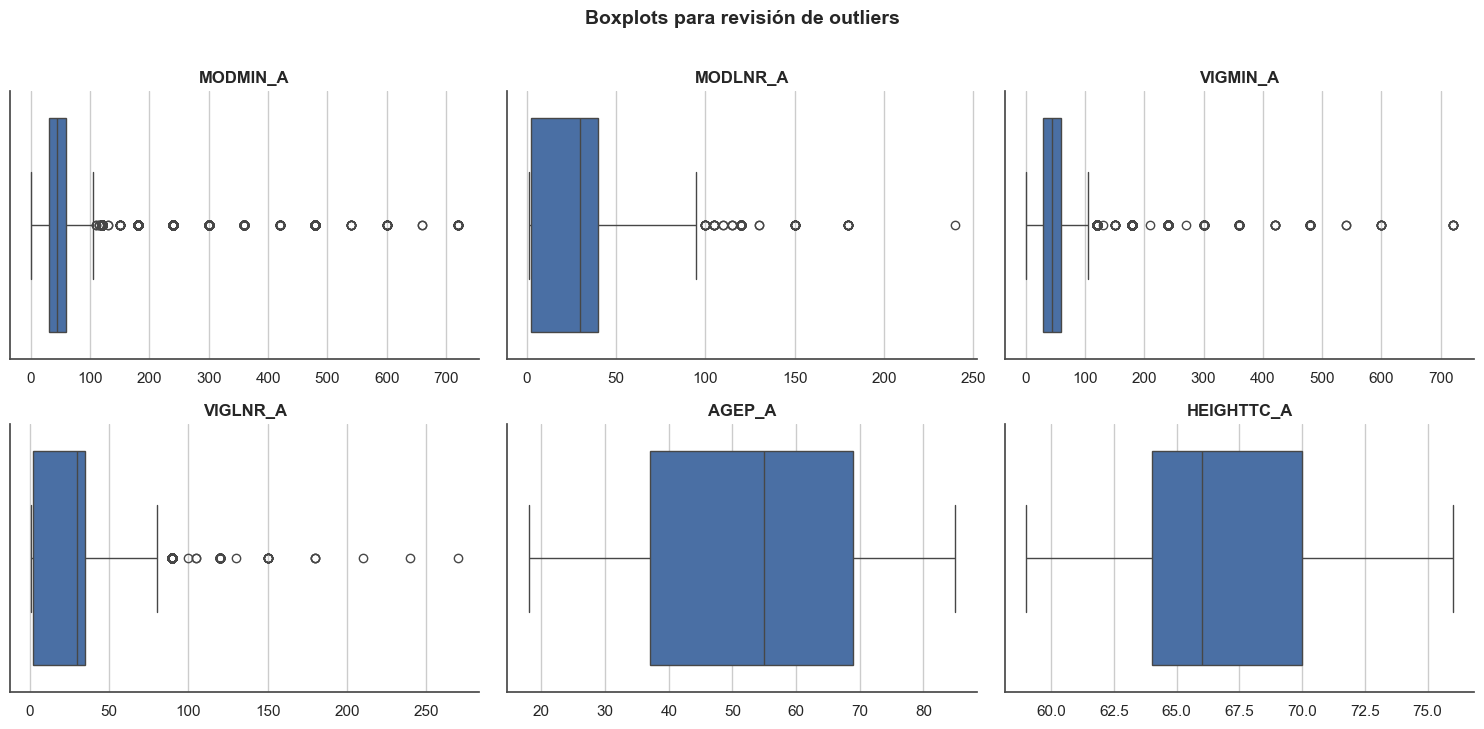

In [248]:
real_numeric_vars = ['MODMIN_A', 'MODLNR_A', 'VIGMIN_A', 'VIGLNR_A', 'AGEP_A', 'HEIGHTTC_A']

def plot_boxplot_var(df, col, ax):
    data = df[col].dropna()
    sns.boxplot(x=data, ax=ax, color=COLOR_BASE)
    ax.set_title(col)
    ax.set_xlabel('')

def num_vars_to_boxplot(df, numvars):
    n_cols = 3
    n_rows = -(-len(numvars) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize= (15, 3.6 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numvars):
        ax = axes[i]
        plot_boxplot_var(df, col, ax)

    for j in range(len(numvars), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Boxplots para revisión de outliers', fontsize = 14, fontweight='bold', y = 1.01)
    plt.tight_layout()
    plt.show()

num_vars_to_boxplot(df_clean_special_codes, real_numeric_vars)


*Observaciones:*
Mi razonamiento al ver estos boxplots se que aun quedan muchos outliers en las variables numericas de actividad física, pero aun siendo outliers, no son errores (que ya fueron limpiados), mas bien son datos que me interesan. Parece que la mayoría de la gente encuestada no hace mucho ejercicio ni moderadamente, pero creo que la relacion entre datos con ejercicio y mi variable objetivo, asi como datos con poco ejercicio y mi variable objetivo, pueden darme informacion interesante.

#### Creación de variable objetivo y

In [ ]:
# Creación de variable objetivo y

# X - > ansiedad preexistente, depresion preexistente, asma crónica, lesiones anteriores, actividad fisica
# Y - > riesgo de lesión o flare up de ansiedad/depresion o flare up de asma

df_y = df_clean_special_codes

# Variable objetivo para evento de lesión

df_y['lesion_repentina'] = np.where(
    df_y['ANYINJURY_A'] == 2, 0,
    np.where(
        df_y['INJLIMIT_A'] == 2, 1,
        np.where(
            df_y['INJSAWDOC_A'] == 2, 2,
            np.where(
                (df_y['INJSAWDOC_A'] == 1) |
                (df_y['INJER_A'] == 1) |
                (df_y['INJHOSP_A'] == 1) |
                (df_y['INJBONES_A'] == 1) |
                (df_y['INJSTITCH_A'] == 1), 3, np.nan
            )
        )
    )
)

df_y['lesion_repetitiva'] = np.where(
    df_y['REPSTRAIN_A'] == 2, 0,
    np.where(
        df_y['REPLIMIT_A'] == 2, 1,
        np.where(
            df_y['REPSAWDOC_A'] == 2, 2,
            np.where(
                df_y['REPSAWDOC_A'] == 1, 3, np.nan
            )
        )
    )
)

tbi_general = np.where(
    df_y['TBIHLSBMC_A'] == 1, 1,
    np.where(
        df_y['TBIHLSBMC_A'] == 2, 0, np.nan
    )
)
tbi_peligro = np.where(
    df_y['TBILCDCMG_A'] == 1, 1,
    np.where(
        df_y['TBILCDCMG_A'] == 2, 0, np.nan
    )
)
tbi_evento = (df_y['TBIHLSBMC_A'] == 1) | (df_y['TBILCDCMG_A'] == 1)
tbi_eval = np.where(
    tbi_evento & (df_y['TBIEVAL_A'] == 1), 1,
    np.where(
        tbi_evento & (df_y['TBIEVAL_A'] == 2), 0,
        np.where(
            ~tbi_evento, 0, np.nan
        )
    )
)

df_y['lesion_cerebral'] = tbi_general + tbi_peligro + tbi_eval


df_y['y_lesion'] = df_y[['lesion_repentina', 'lesion_repetitiva', 'lesion_cerebral']].max(axis=1)

# Variable objetivo para evento malestar psicológico

  # --- Escala K6 (malestar psicológico) ---
    # 'SAD_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},


def calculate_k6_score(n_sad, n_nerv, n_rest, n_hope, n_eff, n_worth):
    #convert points
    #sum points


k6_cols = ['SAD_A', 'NERVOUS_A', 'RESTLESS_A', 'HOPELESS_A', 'EFFORT_A', 'WORTHLESS_A']
k6_score = df_y.apply(lambda row:
                      calculate_k6_score(row['SAD_A'], row['NERVOUS_A'], row['RESTLESS_A'], row['EFFORT_A'], row['WORTHLESS_A'])
                      axis=1)

df_y['y_malestar_psicologico'] = ???

y_malestar_psicologico = ''

# Variable objetivo para evento flare up respiratorio

df_y['y_respiratorio'] = np.where(
    df_y['ASAT12M_A'] == 1, 1,
    np.where(
        df_y['ASAT12M_A'] == 2, 0, np.nan
    )
)







In [84]:
# comprobar balanceo de clases

#### Correlación

In [82]:
# Correlación y colinealidad


## Módulo 2: Feature Engineering

### Limpieza de datos

### Transformaciones

In [85]:
# Abordar duplicados, atipicos, missing values 

### TODO

Redundancia en variables de actividad física: MODNR_A/MODTPR_A y VIGNR_A/VIGTPR_A 
son los componentes crudos (número + unidad de tiempo) que ya están combinados en 
MODFREQW_A/VIGFREQW_A (tasa estandarizada de veces/semana). Mismo patrón para 
MODLNR_A/MODLTPR_A y VIGLNR_A/VIGLTPR_A, ya combinados en MODMIN_A/VIGMIN_A.

Decisión pendiente: evaluar si conservar solo las variables ya estandarizadas 
(*FREQW_A, *MIN_A) como features del modelo, y dejar las variables crudas 
(*NR_A, *TPR_A, *LNR_A, *LTPR_A) únicamente como columnas de auditoría/QA 
del EDA, sin pasarlas al modelo final (para evitar multicolinealidad/redundancia).

In [87]:
# MODLTPR_A: MODLTPR_A -> categorias de unidad de tiempo
# 1.0    15139
# 2.0     7548
# 9.0       87
# 6.0       12
# 8.0        6
# 7.0        5
"mapping = {'1':'minutes', '2':'hours', '7':'refused', '9':'dont_know', '':'missing'}",

("mapping = {'1':'minutes', '2':'hours', '7':'refused', '9':'dont_know', '':'missing'}",)

In [88]:
#VIGFREQW_A

# Mapear códigos especiales (7,9,96–99, etc.) a NA.
# Tratar 94 como "no hizo actividad" (NA o 0 según cómo quieras contar inactividad).
# Usar los valores 0..n como times_per_week y luego combinar con minutos por sesión (VIGMIN_A) para calcular minutos/semana = times_per_week * minutes_per_session (convertir unidades si hacen falta).

# Es una recodificación de “veces por semana” (0,1,2,3,...).
# Contiene códigos especiales (7,9,96–99) y un código muy frecuente 94 que en el fichero aparece emparejado con ausencia de VIGNR/VIGMIN, por lo que conviene mapearlo antes de usarla como número.
# Resultado práctico: usar VIGFREQW_A como variable numérica continua (times/week) después de limpieza; además crear una variable categórica (por ejemplo: inactive/insufficient/sufficient) para análisis y reglas.

In [89]:
# convertir HEIGHTTC_A (pulgadas) a cm y tratar códigos especiales
import numpy as np
df_raw['HEIGHT_in'] = pd.to_numeric(df_raw['HEIGHTTC_A'], errors='coerce')
# marcar códigos >=96 como NA (ajusta según el codebook si confirma otros códigos)
df_raw.loc[df_raw['HEIGHT_in'].isin([96,97,98,99]), 'HEIGHT_in'] = np.nan
df_raw['HEIGHT_cm'] = df_raw['HEIGHT_in'] * 2.54
# comprobar
print(df_raw['HEIGHT_in'].value_counts().head(10))
print(df_raw['HEIGHT_cm'].describe())

HEIGHT_in
66.0    2908
64.0    2857
67.0    2629
65.0    2361
63.0    2337
68.0    2302
69.0    2241
70.0    2216
62.0    2101
72.0    1682
Name: count, dtype: int64
count    30343.000000
mean       169.407946
std          9.940068
min        149.860000
25%        162.560000
50%        167.640000
75%        177.800000
max        193.040000
Name: HEIGHT_cm, dtype: float64


## Módulo 3: Model Tuning

### Tuneado de Modelos

## Módulo 4: Evaluación

3 targets, uno por dominio
combinados en 1 target general de riesgo

### Métricas

### Comparación